<a href="https://colab.research.google.com/github/vituhaa/Healthy-Posture/blob/project/movenet_experiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Использование MoveNet: https://www.tensorflow.org/hub/tutorials/movenet?hl=ru

Оригинальный эксперимент: https://dl.acm.org/doi/epdf/10.1145/3663976.3664014

In [ ]:
! pip install -q imageio
! pip install -q git+https://github.com/tensorflow/docs
! pip install matplotlib==3.9.0

In [31]:
import tensorflow as tf
import tensorflow_hub as tf_hub
import numpy as np
import cv2
import imageio
import os
from tensorflow_docs.vis import embed
from matplotlib import pyplot as plt
from matplotlib.collections import LineCollection

from tensorflow.keras.losses import MeanAbsoluteError
import tensorflow.keras as keras
from tensorflow.keras import layers, models, applications
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
import joblib

from sklearn.metrics import confusion_matrix
import seaborn as sns

movenet_lightning

In [2]:
model_lightning = tf_hub.load("https://tfhub.dev/google/movenet/singlepose/lightning/4")
size_lightning = 192

In [ ]:
signature = model_lightning.signatures["serving_default"]
print(signature.structured_outputs.keys())
print(model_lightning.signatures.keys())

In [ ]:
# получаю предсказания модели на фотографии
def detection(image_path, model, input_size):
  image = tf.io.read_file(image_path)
  image = tf.image.decode_jpeg(image)
  img = tf.expand_dims(image, axis=0)
  resized_img = tf.image.resize_with_pad(img, input_size, input_size)
  img_np = resized_img.numpy().astype(np.int32)
  output = model.signatures["serving_default"](tf.constant(img_np))
  keypoints = output['output_0'].numpy()
  return keypoints

input_image_path = '/content/frame_0016.jpg'
keypoints = detection(input_image_path, model_lightning, size_lightning)
print(keypoints[0][0])

In [ ]:
points = ['nose', 'left_eye', 'right_eye', 'left_ear', 'right_ear', 'left_shoulder', 'right_shoulder']
# цифры в connections - индексы в points, нос связан с глазами (0, 1) и (0, 2) и тд.
connections = [(0, 1), (0, 2), (1, 3), (2, 4), (0, 5), (0, 6), (5, 6)]
def make_skeleton(keypoints, image, image_height, image_width):
  # num_people = keypoints.shape[0]
  fig, ax = plt.subplots(figsize=(12 * (float(image_width) / image_height), 12))
  scat = ax.scatter([], [], s=60, color='#FF1333', zorder=3)
  background_image = ax.imshow(image)
  arr_edges = []
  for i in range(1):
    seven_points = keypoints[i][0][:7]
    # print(seven_points)
    x = [a[1] for a in seven_points]
    y = [a[0] for a in seven_points]
    arr_coordinates_x = [float(coordinate) * image_width for coordinate in x]
    arr_coordinates_y = [float(coordinate) * image_height for coordinate in y]
  arr_coord_point_1 = []
  arr_coord_point_2 = []
  for i in range(len(connections)):
    point_1 = connections[i][0]
    point_2 = connections[i][1]
    coord_point_1 = (round(arr_coordinates_x[point_1], 4), round(arr_coordinates_y[point_1], 4)) # кортеж координат первой точки
    coord_point_2 = (round(arr_coordinates_x[point_2], 4), round(arr_coordinates_y[point_2], 4)) # кортеж координат второй точки
    arr_coord_point_1.append(coord_point_1)
    arr_coord_point_2.append(coord_point_2)

  # print(arr_coord_point_1)
  # print(arr_coord_point_2)
  coord_points = np.stack([arr_coord_point_1, arr_coord_point_2], axis=1)
  coord_concat = np.concatenate(coord_points, axis=0)

  lines = np.array([arr_coord_point_1, arr_coord_point_2])
  merged_lines = np.stack(lines, axis=1)
  line_collection = LineCollection([], linewidths=(4), linestyle='solid')
  ax.add_collection(line_collection)
  line_collection.set_segments(merged_lines)
  scat.set_offsets(coord_concat)


# тестирование функции:
def resize_image(img_path, model_size):
  input_image = tf.io.read_file(img_path)
  input_image = tf.image.decode_jpeg(input_image)
  # print(input_image.shape)
  picture = tf.expand_dims(input_image, axis=0)
  picture = tf.image.resize_with_pad(picture, model_size, model_size)
  # print(picture.shape)
  display_pic = tf.expand_dims(input_image, axis=0)
  display_pic = tf.cast(tf.image.resize_with_pad(display_pic, 1280, 1280), dtype=tf.int32)
  result_image = np.squeeze(display_pic.numpy(), axis=0)
  # print(result_image.shape)
  image_height, image_width, a = result_image.shape
  return result_image, image_height, image_width

result_image, image_height, image_width = resize_image(input_image_path, size_lightning)
make_skeleton(keypoints, result_image, image_height, image_width)


In [ ]:
# визуальная проверка качества вывода модели
def check_dataset_skeletons(dataset_path):
  for x in os.listdir(dataset_path):
    photo_path = dataset_path + '/' + x
    kpts = detection(photo_path, model_lightning, size_lightning)
    # print(kpts)
    result_image, image_height, image_width = resize_image(photo_path, size_lightning)
    make_skeleton(kpts, result_image, image_height, image_width)
check_dataset_skeletons("/content/drive/MyDrive/sitting_pose_dataset")

Проверим исходные модели movenet_lightning на качество на датасете с сидячими людьми (80 фотографий).

Метрика PCK:

In [6]:
## COCO FORMAT:
# 0 - nose,
# 1 - neck,
# 2 - right_shoulder,
# 3 - right_elbow,
# 4 - right_wrist,
# 5 - left_shoulder,
# 6 - left_elbow,
# 7 - left_wrist,
# 8 - right_hip,
# 9 - right_knee,
# 10 - right_ankle,
# 11 - left_hip,
# 12 - left_knee,
# 13 - left_ankle,
# 14 - right_eye,
# 15 - left_eye,
# 16 - right_ear,
# 17 - left_ear

# MoveNet FORMAT: ['nose', 'left_eye', 'right_eye', 'left_ear', 'right_ear', 'left_shoulder', 'right_shoulder']

# проверка исходной модели на качество в разрезе нашей задачи:
import os
import json

val_dataset_path = '/content/drive/MyDrive/датасет для курсовой работы, 3 курс/sitting_pose_dataset/'
val_dataset_frames = []
sorted_dataset = []
for x in os.listdir(val_dataset_path):
  val_dataset_frames.append(x)
sorted_dataset = sorted(val_dataset_frames)

def make_predictions(model, model_size, dataset_path, dataset): # подаю датасет, получаю точки от модели
  pairs_xy = []
  num = 0
  for photo in dataset:
    image_path = dataset_path + str(photo)
    photo_keypoints = detection(image_path, model, model_size)
    input_image = tf.io.read_file(image_path)
    input_image = tf.image.decode_jpeg(input_image)
    height, width, _ = input_image.shape
    if (len(photo_keypoints.shape) == 4):
      resized_x = photo_keypoints[0, 0, :, 1] * width
      resized_y = photo_keypoints[0, 0, :, 0] * height
    elif (len(photo_keypoints.shape) == 3):
      print(photo_keypoints)
      print(photo_keypoints[0, :, 0])
      print(photo_keypoints[0, :, 1])
      resized_x = photo_keypoints[0, :, 1] * width
      resized_y = photo_keypoints[0, :, 0] * height
    for i in range(0, 7):
      pairs_xy.append((resized_x[i], resized_y[i]))
    num += 1
  return (pairs_xy)

def extract_ideal_annotations(true_annotations): # подаю ground_truth аннотации из файла, получаю списки
                                                 # нужных точек
  with open(true_annotations, "r", encoding="utf-8") as ground_truth:
    info = json.load(ground_truth)
  arr = []
  extracted_keypoints = []
  for x in info.get("annotations"):
    arr.append(x.get("keypoints"))
  for i in range(len(arr)):
    clean_arr = []
    if str(arr[i]) != "None":
      tmp = arr[i]
      clean_arr.append([tmp[0], tmp[1]]) # tmp[2],  nose
      clean_arr.append([tmp[45], tmp[46]]) # tmp[47], left_eye
      clean_arr.append([tmp[42], tmp[43]]) # tmp[44], right_eye
      clean_arr.append([tmp[51], tmp[52]]) # tmp[53], left_ear
      clean_arr.append([tmp[48], tmp[49]]) # tmp[50], right_ear
      clean_arr.append([tmp[15], tmp[16]]) # tmp[17], left_shoulder
      clean_arr.append([tmp[6], tmp[7]]) # tmp[8]] right_shoulder
      extracted_keypoints.append(clean_arr)
  return extracted_keypoints

In [7]:
# получаем предсказания на всём валидационном датасете
prediction_pairs_xy = make_predictions(model_lightning, size_lightning, val_dataset_path, sorted_dataset)
# print(*[f"{np.float32(x)}, \n" for x in prediction_pairs_xy])

In [8]:
# получаем идеальные точки разметки для датасета на 80
extracted_ideal_keypoints80 = extract_ideal_annotations("/content/result_TRUE80.json")
ideal_keypoints_list80 = []
for x in extracted_ideal_keypoints80:
  for pair in x:
    ideal_keypoints_list80.append(pair)
# print(*[f"{x},\n" for x in extracted_ideal_keypoints80])

In [ ]:
# пример того, как выглядит скелет на фотографии 720 * 1280 с координатами из идеальной разметки
def draw_image_ex(pic, image_height, image_width):
  fig, ax = plt.subplots(figsize=(12 * (float(image_width) / image_height), 12))
  scat = ax.scatter([], [], s=60, color='#FF1333', zorder=3)
  background_image = ax.imshow(image)
  arr_edges = []
  x = [610, 687, 565, 781, 504, 878, 371]
  y = [221, 187, 189, 254, 262, 480, 469]
  arr_coordinates_x = [float(coordinate) for coordinate in x]
  arr_coordinates_y = [float(coordinate) for coordinate in y]
  arr_coord_point_1 = []
  arr_coord_point_2 = []
  for i in range(len(connections)):
    point_1 = connections[i][0]
    point_2 = connections[i][1]
    coord_point_1 = (round(arr_coordinates_x[point_1], 4), round(arr_coordinates_y[point_1], 4)) # кортеж координат первой точки
    coord_point_2 = (round(arr_coordinates_x[point_2], 4), round(arr_coordinates_y[point_2], 4)) # кортеж координат второй точки
    arr_coord_point_1.append(coord_point_1)
    arr_coord_point_2.append(coord_point_2)

  print(arr_coord_point_1)
  print(arr_coord_point_2)
  coord_points = np.stack([arr_coord_point_1, arr_coord_point_2], axis=1)
  coord_concat = np.concatenate(coord_points, axis=0)

  lines = np.array([arr_coord_point_1, arr_coord_point_2])
  merged_lines = np.stack(lines, axis=1)
  line_collection = LineCollection([], linewidths=(4), linestyle='solid')
  ax.add_collection(line_collection)
  line_collection.set_segments(merged_lines)
  scat.set_offsets(coord_concat)

image = tf.io.read_file("/content/frame_0016.jpg")
image = tf.image.decode_jpeg(image)
print(image.shape)
image_height, image_width, alpha = image.shape
draw_image_ex(image, image_height, image_width)

In [10]:
def percentage_of_correct_keypoints(predictions, ground_truth, alpha): # метрика PCK
  num_keypoints = 7
  sum = 0
  formula = 0
  arr_left_ear = []
  arr_right_shoulder = []
  output = []
  for i in range(3, len(ground_truth), 7):
    arr_left_ear.append(ground_truth[i])
  for i in range(6, len(ground_truth), 7):
    arr_right_shoulder.append(ground_truth[i])
  for i in range(len(predictions)): # 560
    if ((i % 7 == 0) or (i == 0)):
      threshold = ((arr_left_ear[int(i / 7)][0] - arr_right_shoulder[int(i / 7)][0]) ** 2 +
       (arr_left_ear[int(i / 7)][1] - arr_right_shoulder[int(i / 7)][1]) ** 2) ** 0.5
    x_ideal = ground_truth[i][0]
    y_ideal = ground_truth[i][1]
    x_predict = predictions[i][0]
    y_predict = predictions[i][1]
    distance = ((x_ideal - x_predict) ** 2 + (y_ideal - y_predict) ** 2) ** 0.5
    if (distance < threshold * alpha):
      sum += 1
  return (sum / len(predictions))

In [11]:
alpha = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
percents_lightning = []
for a in alpha:
  percent = percentage_of_correct_keypoints(prediction_pairs_xy, ideal_keypoints_list80, a)
  percents_lightning.append(round(percent * 100, 3))
print(percents_lightning)

[41.964, 72.321, 87.143, 88.929, 90.179, 90.357, 90.357, 90.357, 90.714, 91.964]


movenet_thunder

In [12]:
model_thunder = tf_hub.load("https://tfhub.dev/google/movenet/singlepose/thunder/4")
size_thunder = 256

In [ ]:
keypoints_thunder = detection(input_image_path, model_thunder, size_thunder)
print(keypoints_thunder)

In [ ]:
input_image = tf.io.read_file(input_image_path)
input_image = tf.image.decode_jpeg(input_image)
# print(input_image.shape)
picture = tf.expand_dims(input_image, axis=0)
picture = tf.image.resize_with_pad(picture, size_thunder, size_thunder)
# print(picture.shape)
display_pic = tf.expand_dims(input_image, axis=0)
display_pic = tf.cast(tf.image.resize_with_pad(display_pic, 1280, 1280), dtype=tf.int32)
result_image = np.squeeze(display_pic.numpy(), axis=0)
image_height, image_width, a = result_image.shape
# print(image_height, image_width)
make_skeleton(keypoints_thunder, result_image, image_height, image_width)

In [15]:
prediction_pairs_xy_thunder = make_predictions(model_thunder, size_thunder, val_dataset_path, sorted_dataset)
# print(*[f"{np.float32(x)}, \n" for x in prediction_pairs_xy_thunder])

In [16]:
alpha = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
percents_thunder = []
for a in alpha:
  percent = percentage_of_correct_keypoints(prediction_pairs_xy_thunder, ideal_keypoints_list80, a)
  percents_thunder.append(round(percent * 100, 3))
print(percents_thunder)

[44.107, 74.107, 88.036, 90.179, 90.179, 90.179, 90.357, 90.357, 90.714, 92.321]


Сравнение метрик качества двух исходных моделей - lightning и thunder

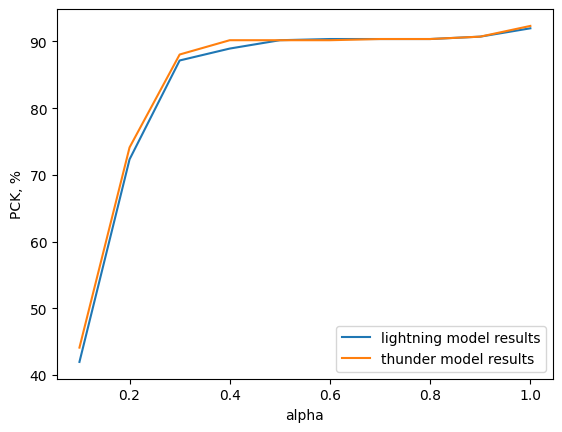

In [17]:
plt.plot(alpha, percents_lightning, label="lightning model results")
plt.plot(alpha, percents_thunder, label="thunder model results")
plt.xlabel('alpha')
plt.ylabel('PCK, %')
plt.legend()
plt.show()

Как видно, модель thunder немного лучше предсказывает ключевые точки на теле сидячего человека, как и было объявлено авторами MoveNet (изначально предполагается, что thunder делает более качественные предсказания).

Классификатор MLP на scikit-learn: https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html

MLP для Lightning

In [18]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
from sklearn.preprocessing import StandardScaler

def metrics_calculation(true, pred):
  metric = {'Accuracy': round(metrics.accuracy_score(true, pred), 3),
            'Precision': round(metrics.precision_score(true, pred, average='macro'), 3),
            'Recall': round(metrics.recall_score(true, pred, average='macro'), 3),
            'F-1': round(metrics.f1_score(true, pred, average='macro'), 3)}
  print("Accuracy: ", metric['Accuracy'])
  print("Precision: ", metric['Precision'])
  print("Recall: ", metric['Recall'])
  print("F-1: ", metric['F-1'])
  return metric

In [19]:
categories = ['head_left', 'head_right', 'correct', 'bend_over', 'body_left', 'body_right', 'tilt_back', 'too_close']

In [20]:
def get_preds_for_all_categories(model, model_size, categories):
  # нужно получить предсказания (x, y) для каждой фотографии - data
  # название класса - target
  X = [] # признаки
  y = [] # классы

  mlp_dataset_path = '/content/drive/MyDrive/датасет для курсовой работы, 3 курс/MoveNet_MLP_dataset/'

  for i in range(len(categories)):
    path = mlp_dataset_path + categories[i] + '/'
    mlp_frames = []
    for x in os.listdir(path):
      y.append(i)
      mlp_frames.append(x)
    sorted_mlp_frames = sorted(mlp_frames)
    preds = make_predictions(model, model_size, path, sorted_mlp_frames)
    for i in range(0, len(preds), 7):
      X.append(preds[i:i+7])

  return X, y

In [21]:
def prepare_for_mlp(model, model_size):
  X_preds, y = get_preds_for_all_categories(model, model_size, categories)
  X = []
  arr = [[tuple(float(a) for a in x) for x in line] for line in X_preds]
  for pairs in arr:
    flat = []
    for x_coord, y_coord in pairs:
      flat.extend([x_coord, y_coord])
    X.append(flat)
  return X, y

In [22]:
X_light, y_light = prepare_for_mlp(model_lightning, size_lightning)
print(print(np.array(X_light).shape))
print(len(y_light))

(1812, 14)
None
1812


In [23]:
# обучение MLP классификатора
from sklearn.model_selection import GridSearchCV

def train_mlp(X, y):
  grid_search_parameters = {
      'alpha': [0.0001, 0.001, 0.01, 0.05, 0.1, 0.15, 0.2, 0.3],
      'hidden_layer_sizes': [(128, 64, 32, 16, 8),
                             (128, 64, 32, 16),
                             (128, 64, 32),
                             (128, 64),
                             (128,),
                             (64, 32, 16, 8),
                             (64, 32, 16),
                             (64, 32),
                             (64,),
                             (32, 16, 8),
                             (32, 16),
                             (32,),
                             (16, 8),
                             (16,),
                             (8,)]
  }

  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

  scaler = StandardScaler()
  scaler.fit(X_train)
  X_train_scaled = scaler.transform(X_train)
  X_test_scaled = scaler.transform(X_test)

  mlp = MLPClassifier(
      # hidden_layer_sizes=hidden_layer_sizes,
      activation='relu',
      # alpha=alpha,
      solver='adam',
      max_iter=5000,
      learning_rate='adaptive',
      learning_rate_init=0.001,
      shuffle=True,
      verbose=False,
      random_state=42
  )

  grid_search_cv = GridSearchCV(mlp, grid_search_parameters, cv=5)
  grid_search_cv.fit(X_train_scaled, y_train)

  best_parameters = grid_search_cv.best_params_
  best_score = grid_search_cv.best_score_
  best_estimator = grid_search_cv.best_estimator_

  y_pred = grid_search_cv.predict(X_test_scaled)
  metrics_calculation(y_test, y_pred)
  return best_parameters, best_score, best_estimator, scaler

In [24]:
best_parameters_lightning, best_score_lightning, mlp_lightning, scaler_lightning = train_mlp(X_light, y_light)
print("Лучшие параметры для Lightning: ", best_parameters_lightning)
print("Лучший средний accuracy для кросс-валидации: ", best_score_lightning)

Accuracy:  0.967
Precision:  0.971
Recall:  0.971
F-1:  0.971
Лучшие параметры для Lightning:  {'alpha': 0.0001, 'hidden_layer_sizes': (128, 64)}
Лучший средний accuracy для кросс-валидации:  0.9675599570456986


In [47]:
def check_mlp_on_test_ds(categories, mlp, scaler, model, model_size):
  name = ''
  if (mlp == mlp_lightning):
    name = 'Lightning'
  else:
    name = 'Thunder'
  # предсказания MoveNet на новых фотографиях, получение данных в нужном формате
  path_example = '/content/drive/MyDrive/датасет для курсовой работы, 3 курс/MoveNet_Test/' # папка с тестами
  arr_new_photos = []
  y_test = []
  class_num = 0
  for i in range(len(categories)):
    category = categories[i]
    cat_path = path_example + category + '/'
    local_dataset = []
    for x in os.listdir(cat_path):
      local_dataset.append(x)
      y_test.append(class_num)
    local_sorted_dataset = sorted(local_dataset)
    class_num += 1
    photos_kpts = make_predictions(model, model_size, cat_path, local_sorted_dataset)
    arr_new_photos.append(photos_kpts)

  # беру координаты для всех тестовых фотографий, урезаю до 7
  X_test = []
  for x in arr_new_photos:
    arr_new = [tuple(float(a) for a in b) for b in x]
    for i in range(0, len(arr_new), 7):
      arr_seven = []
      arr_seven = arr_new[i:i+7]
      X_new = []
      for x_coord, y_coord in arr_seven:
        X_new.append(x_coord)
        X_new.append(y_coord)
      X_test.append(X_new)

  # проверка предсказанной категории для каждой новой фотографии
  y_pred_arr = []
  for frame in X_test:
    features = np.array(frame).reshape(1, -1)
    X_new_scaled = scaler.transform(features)
    pred_new = mlp.predict(X_new_scaled)
    y_pred_arr.append(pred_new.item())
    prob_new = mlp.predict_proba(X_new_scaled)

  matrix = confusion_matrix(y_test, y_pred_arr)
  sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues')
  plt.xlabel('Predictions')
  plt.ylabel('True')
  plt.title(f'{name} confusion matrix')
  plt.show()

  metrics_calculation(y_test, y_pred_arr)

Lightning MoveNet results on test dataset: 



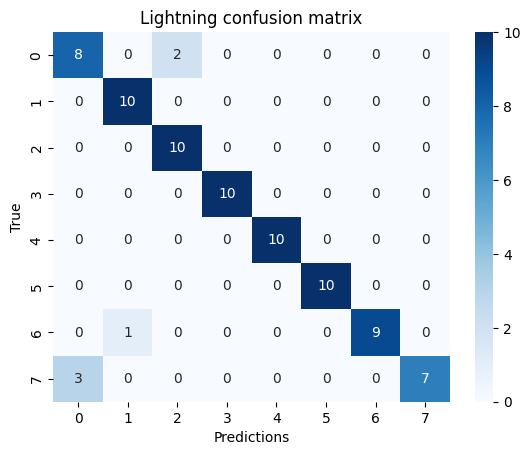

Accuracy:  0.925
Precision:  0.934
Recall:  0.925
F-1:  0.924


In [48]:
print("Lightning MoveNet results on test dataset: \n")
check_mlp_on_test_ds(categories, mlp_lightning, scaler_lightning, model_lightning, size_lightning)

In [ ]:
categories = ['head_left', 'head_right', 'correct', 'bend_over', 'body_left', 'body_right', 'tilt_back', 'too_close']

In [27]:
joblib.dump(scaler_lightning, 'scaler_lightning.joblib') # скачиваю scaler
joblib.dump(mlp_lightning, 'mlp_lightning.joblib') # скачиваю модель

['mlp_lightning.joblib']

MLP для Thunder

In [28]:
X_thunder, y_thunder = prepare_for_mlp(model_thunder, size_thunder)
print(print(np.array(X_thunder).shape))
print(len(y_thunder))

(1812, 14)
None
1812


In [33]:
best_parameters_thunder, best_score_thunder, mlp_thunder, scaler_thunder = train_mlp(X_thunder, y_thunder)
print("Лучшие параметры для Thunder: ", best_parameters_thunder)
print("Лучший средний accuracy для кросс-валидации: ", best_score_thunder)

Accuracy:  0.964
Precision:  0.968
Recall:  0.969
F-1:  0.968
Лучшие параметры для Thunder:  {'alpha': 0.001, 'hidden_layer_sizes': (128, 64, 32)}
Лучший средний accuracy для кросс-валидации:  0.9737644672473452


Thunder MoveNet results on test dataset: 



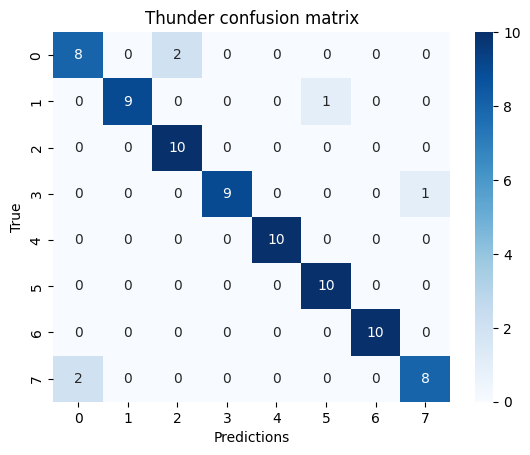

Accuracy:  0.925
Precision:  0.929
Recall:  0.925
F-1:  0.925


In [49]:
print("Thunder MoveNet results on test dataset: \n")
check_mlp_on_test_ds(categories, mlp_thunder, scaler_thunder, model_thunder, size_thunder)

In [35]:
joblib.dump(scaler_thunder, 'scaler_thunder.joblib') # скачиваю scaler
joblib.dump(mlp_thunder, 'mlp_thunder.joblib') # скачиваю модель

['mlp_thunder.joblib']